In [1]:
# Imports
import os
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors, KernelDensity
from sklearn.cluster import MeanShift, estimate_bandwidth
from scipy.special import digamma
from math import pi, gamma

In [2]:
# Load functions
def preprocess_image(image):
        preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
                             ])
        return preprocess(image)

In [3]:
# Load ResNet50-model
num_classes = 1081
resnet_checkpoint_path = 'models/pretrained/resnet50_weights_best_acc.tar'

try:
    model = resnet50(num_classes=num_classes)
    model = torch.nn.Sequential(*(list(model.children())[:-1]))
    checkpoint = torch.load(resnet_checkpoint_path, map_location='cpu', weights_only=True)
    state_dict = checkpoint.get('state_dict', checkpoint)
    model.load_state_dict(state_dict=state_dict, strict=False)
    print("ResNet loaded succesfully")
except Exception as e:
    print(f"Error loading ResNet: {e}")

model.eval()
frames = os.listdir("data/divers1/")
embeddings = []

for i, frame in enumerate(frames):
    img = Image.open("data/divers1/" + frame)
    preprocessed_img = preprocess_image(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)

    embeddings.append(features.cpu().numpy().flatten())

embeddingspace = np.array(embeddings)
embeddingspace_norm = normalize(embeddingspace, axis=1)

ResNet loaded succesfully


Densiteit volgens histogrammen

In [4]:
# # Pairwise distances
# distances = pairwise_distances(embeddingspace_norm, metric='euclidean')
# distances = distances[np.triu_indices_from(distances, k=1)]

# print(distances.shape)

# plt.figure(figsize=(8, 5))
# plt.hist(distances, bins=100, color='skyblue', edgecolor='black')
# plt.title('Histogram of pairwise distances in embedding space')
# plt.xlabel('Distance')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()

In [5]:
# # 1000 points uniformly on hypersphere (approximation)
# embedding = np.random.randn(100, 2048)
# embedding /= np.linalg.norm(embedding, axis=1, keepdims=True)

# # Pairwise distances
# distances = pairwise_distances(embedding, metric='euclidean')
# distances = distances[np.triu_indices_from(distances, k=1)]

# plt.hist(distances, bins=100, color='limegreen', edgecolor='black')
# plt.title('Histogram of ideal pairwise distances in embedding space')
# plt.xlabel('Distance')
# plt.ylabel('Frequency')
# plt.grid(True)
# plt.show()

Kwantitatieve densiteit volgens kNN, KDE en globale densiteit.

In [6]:
# kNN density estimation
# Dimensionality reduction
pca = PCA(n_components=50, random_state=42)
embeddingspace_reduced = pca.fit_transform(embeddingspace)

k = 20
nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace_reduced)
distances, indices = nbrs.kneighbors(embeddingspace_reduced)

# Remove distance to self (first column)
distances = distances[:, 1:]

density = 1 / (np.mean(distances, axis=1) + 1e-10)
average_density = np.mean(density)
# norm_density = (density - density.min()) / (density.max() - density.min())

# print(density)
print(average_density)

33.51421


In [7]:
# # KDE - Not working
# # Dimensionality reduction
# pca = PCA(n_components=30, random_state=42)
# embeddingspace_reduced = pca.fit_transform(embeddingspace)

# # Fit KDE on reduced embedding
# bandwidth = 0.5
# kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
# kde.fit(embeddingspace_reduced)

# # Calculate densities
# log_density = kde.score_samples(embeddingspace_reduced)
# density = np.exp(log_density)

# print(density)

In [8]:
# Global density approximation
distances = pairwise_distances(embeddingspace)
mean_distance = distances[np.triu_indices_from(distances, k=1)].mean()
global_density = 1 / (mean_distance + 1e-12)

print(global_density)

0.006331817945548413


Visuele densiteit met behulp van kNN en MeanShift (KDE wordt hier niet gebruikt).

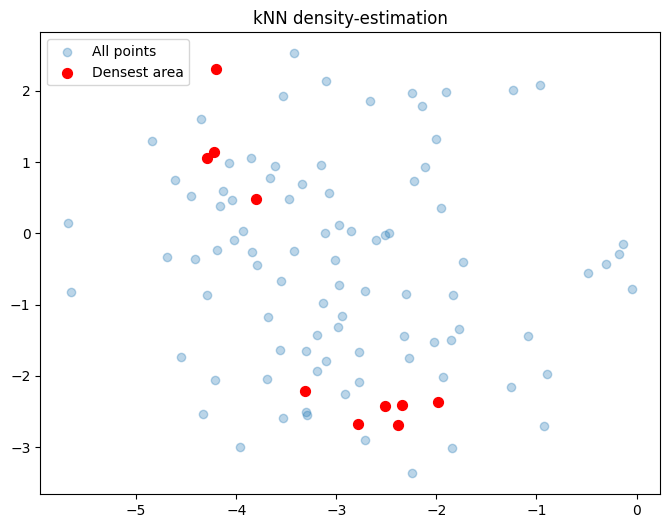

In [39]:
# Dimensionality reduction recommended to prevent Gamma function overflow
pca = PCA(n_components=50, random_state=42)
embeddingspace_reduced = pca.fit_transform(embeddingspace_norm)

k = 20
nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace_reduced)
distances, indices = nbrs.kneighbors(embeddingspace_reduced)

# Remove distance to self (first column)
distances = distances[:, 1:]

density = 1 / (np.mean(distances, axis=1) + 1e-10)

top_k_points = 10
top_indices = np.argsort(density)[-top_k_points:]

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
reduced_embedding = tsne.fit_transform(embeddingspace_norm)

plt.figure(figsize=(8, 6))
plt.scatter(reduced_embedding[:, 0], reduced_embedding[:, 1], alpha=0.3, label='All points')
plt.scatter(reduced_embedding[top_indices, 0], reduced_embedding[top_indices, 1], color='red', label='Densest area', s=50)
plt.title("kNN density-estimation")
plt.legend()
plt.show()

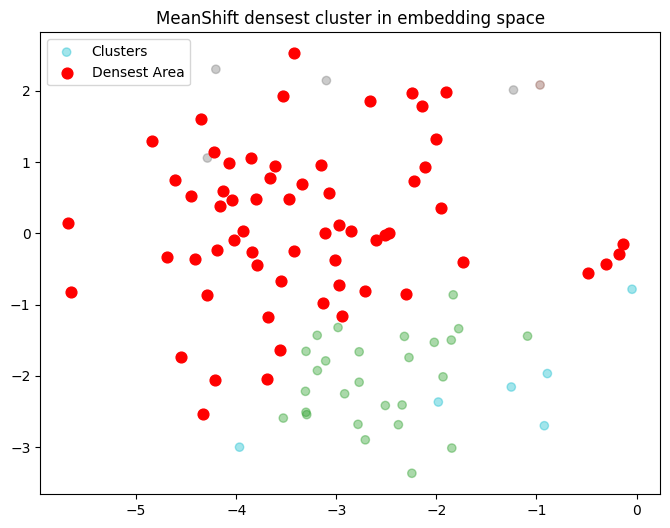

In [34]:
# Dimensionality reduction recommended
pca = PCA(n_components=50, random_state=42)
embeddingspace_reduced = pca.fit_transform(embeddingspace_norm)

bandwidth = estimate_bandwidth(embeddingspace_reduced, quantile=0.2, n_samples=100)
meanshift = MeanShift(bandwidth=0.01, bin_seeding=True)
meanshift.fit(embeddingspace_reduced)

labels = meanshift.labels_ # Assing each point to clusters
cluster_centers = meanshift.cluster_centers_ # Cluster centers

# Find densest cluster
unique_labels, counts = np.unique(labels, return_counts=True)
densest_cluster_label = unique_labels[np.argmax(counts)]

dense_indices = np.where(labels == densest_cluster_label)[0]

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
reduced_embedding = tsne.fit_transform(embeddingspace_norm)

# Visualize densest area
plt.figure(figsize=(8, 6))
plt.scatter(reduced_embedding[:, 0], reduced_embedding[:, 1], c=labels, cmap='tab10', alpha=0.4, label='Clusters')
plt.scatter(reduced_embedding[dense_indices, 0], reduced_embedding[dense_indices, 1], color='red', label='Densest Area', s=60)
plt.title("MeanShift densest cluster in embedding space")
plt.legend()
plt.show()

In [41]:
k = min(k + 1, embeddingspace.shape[0]) # +1 om punt zelf mee te rekenen in kNN

# Bereken afstandne tot k dichtste buren
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(embeddingspace)
distances, _ = nbrs.kneighbors(embeddingspace)

# Afstand tot zichzelf (eerste kolom) niet meerekenen, bereken gemiddelde afstand tot buren
avg_distances = np.mean(distances[:, 1:], axis=1)

# Kleinere avg_distances = meer dense -> snoeien
num_to_prune = int(0.05 * embeddingspace.shape[0])
prune_indices = np.argsort(avg_distances)[:num_to_prune]

# Prune mask opstellen
mask = np.ones(embeddingspace.shape[0], dtype=bool)
mask[prune_indices] = False

print(mask)

[ True  True  True False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
 False  True  True  True  True  True  True  True  True False  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False  True False  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True]


In [ ]:
pca = PCA(n_components=50, random_state=42)
embeddingspace_reduced = pca.fit_transform(embeddingspace)

k = 20
nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace_reduced)
distances, indices = nbrs.kneighbors(embeddingspace_reduced)

# Remove distance to self (first column)
distances = distances[:, 1:]

density = 1 / (np.mean(distances, axis=1) + 1e-10)
average_density = np.mean(density)
# norm_density = (density - density.min()) / (density.max() - density.min())

print(average_density)

In [ ]:
distances = pairwise_distances(embeddingspace)
mean_distance = distances[np.triu_indices_from(distances, k=1)].mean()
global_density = 1 / (mean_distance + 1e-12)
print(global_density)

In [ ]:
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
embeddings_2d = tsne.fit_transform(embeddingspace)

pruned_embedding = embeddings_2d[mask]

embeddingspace = embeddingspace[mask]

k = 10  # number of neighbors to consider
nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='auto').fit(embeddingspace)
distances, _ = nbrs.kneighbors(embeddingspace)

# Ignore the first column (distance to self = 0)
avg_distance = distances[:, 1:].mean(axis=1)
density = 1 / (avg_distance + 1e-6)  # Inverse of average distance = absolute density estimate

# if density_min == None and density_max == None:
#     density_min = density.min()
#     density_max = density.max()

# Plot: density as brightness on scatter plot
plt.figure(figsize=(8, 6))

# Create scatter plot with absolute density color
sc = plt.scatter(pruned_embedding[:, 0],
                 pruned_embedding[:, 1],
                 c=density,
                 cmap='viridis',
                 s=60,
                 edgecolors='none')

plt.title('t-SNE embedding met absolute density')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(sc, label='Density')
plt.grid(True)
plt.tight_layout()
plt.show()